In [1]:
import importlib
import logging
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

logging.basicConfig()
logging.getLogger().setLevel(logging.INFO)

from datetime import datetime
from portfolio_optimization import *
import numpy as np

# S&P and Dow Jones Tickers
sp_dj_asset_tickers = {
    "SPY": "U.S. Equities",                     # SPDR S&P 500 ETF Trust                     
    "SPDW": "International Equities",           # SPDR Portfolio Developed World ex-US ETF
    "SPEM": "Emerging Market Equities",         # SPDR Portfolio Emerging Markets ETF
    "RWX": "Real Estate",                       # SPDR Dow Jones International Real Estate ETF (RWX)
    "^SPGSCI": "Commodities",                     # Dow Jones Commodity Index
    "LQD": "Investment-Grade Bonds",            # S&P 500 Bond Index
    "SPHY": "High-Yield Bonds",                 # SPDR Portfolio High Yield Bond ETF
    "BWX": "International Sovereign Bonds"      # SPDR Bloomberg International Treasury Bond ETF
}


trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '1998-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn -q

In [3]:
tickers = dict(sp_dj_asset_tickers)

returns_df = download_tickers_returns(tickers=tickers, start_date="1998-12-23", cache_path="../data/historical-asset-classes-returns.csv")
returns_df.head()

,U.S. Equities,International Equities,Emerging Market Equities,Real Estate,Commodities,Investment-Grade Bonds,High-Yield Bonds,International Sovereign Bonds
Date,,,,,,,,
1998-12-24,-0.004311,0.0,0.0,0.0,0.000231,0.0,0.0,0.0
1998-12-28,-0.002548,0.0,0.0,0.0,0.005541,0.0,0.0,0.0
1998-12-29,0.015832,0.0,0.0,0.0,0.010102,0.0,0.0,0.0
1998-12-30,-0.008044,0.0,0.0,0.0,-0.002349,0.0,0.0,0.0
1998-12-31,0.000000,0.0,0.0,0.0,0.010253,0.0,0.0,0.0


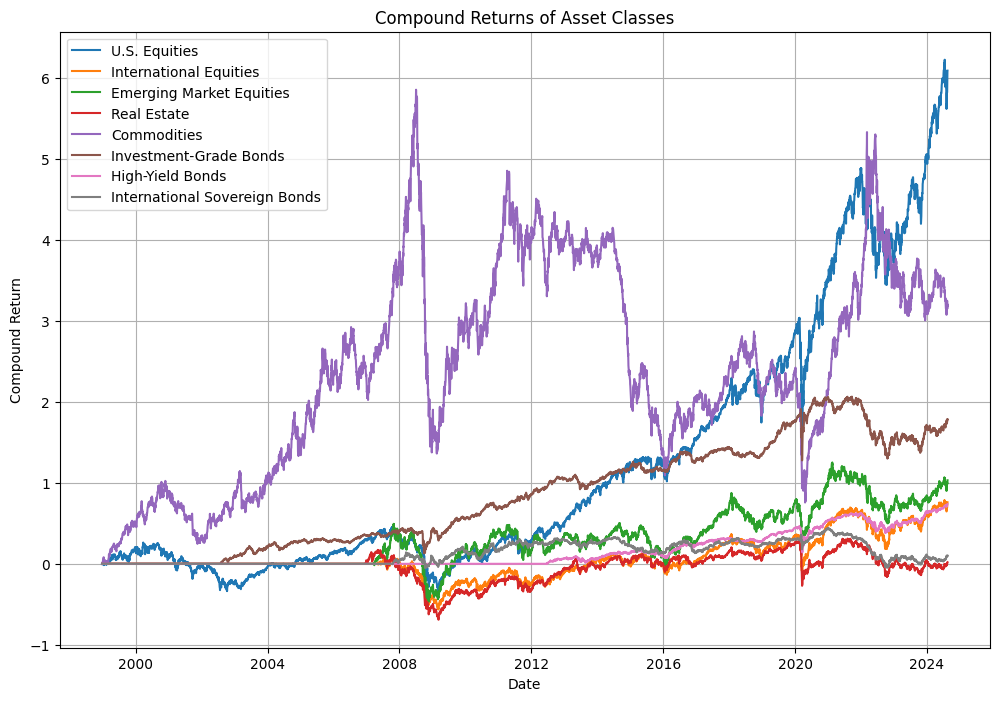

In [4]:
# Calculate compound returns
compound_returns = (1 + returns_df).cumprod() - 1

# Plot the compound returns
plt.figure(figsize=(12, 8))
for column in compound_returns.columns:
    plt.plot(compound_returns.index, compound_returns[column], label=column)

plt.title('Compound Returns of Asset Classes')
plt.ylabel('Compound Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

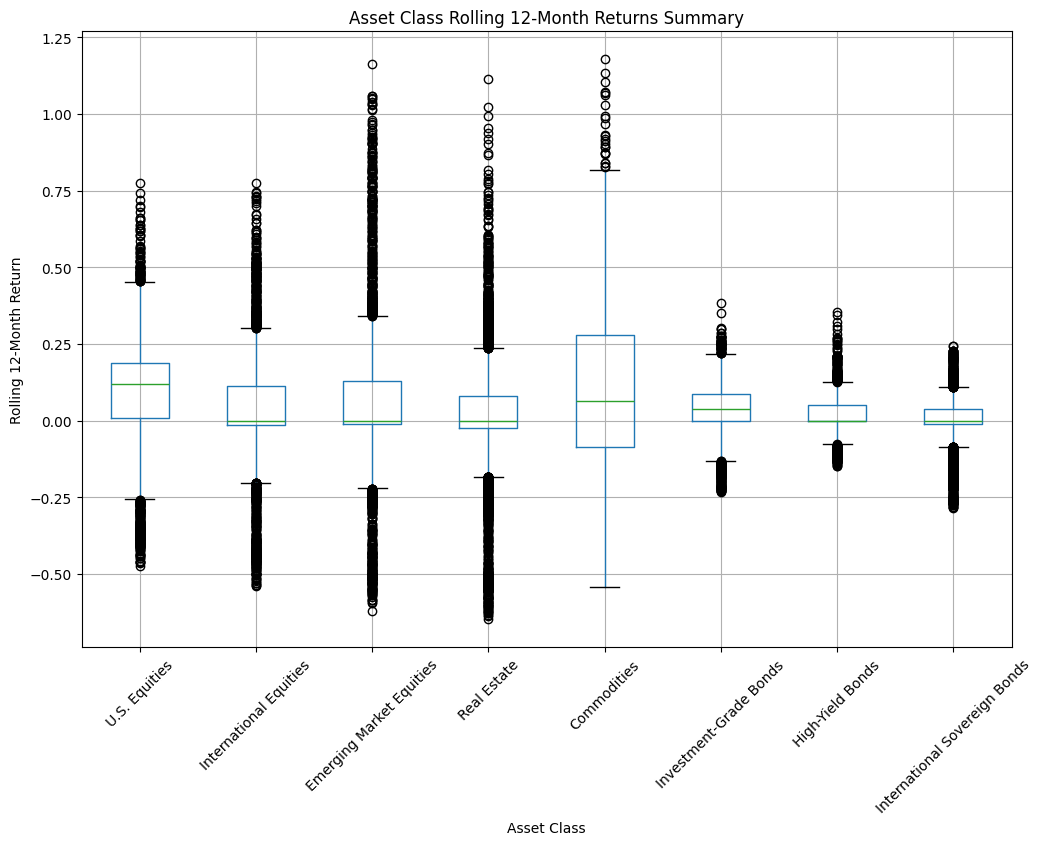

In [5]:
trading_days_in_year = 252  # Approximate number of trading days in a year

# Calculate 12-month rolling returns by compounding
rolling_returns = (1 + returns_df).rolling(window=trading_days_in_year).apply(lambda x: x.prod() - 1)
rolling_returns = rolling_returns.dropna()

# box and whisker chart for rolling 12-month returns
plt.figure(figsize=(12, 8))
rolling_returns.boxplot()
plt.title('Asset Class Rolling 12-Month Returns Summary')
plt.ylabel('Rolling 12-Month Return')
plt.xlabel('Asset Class')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

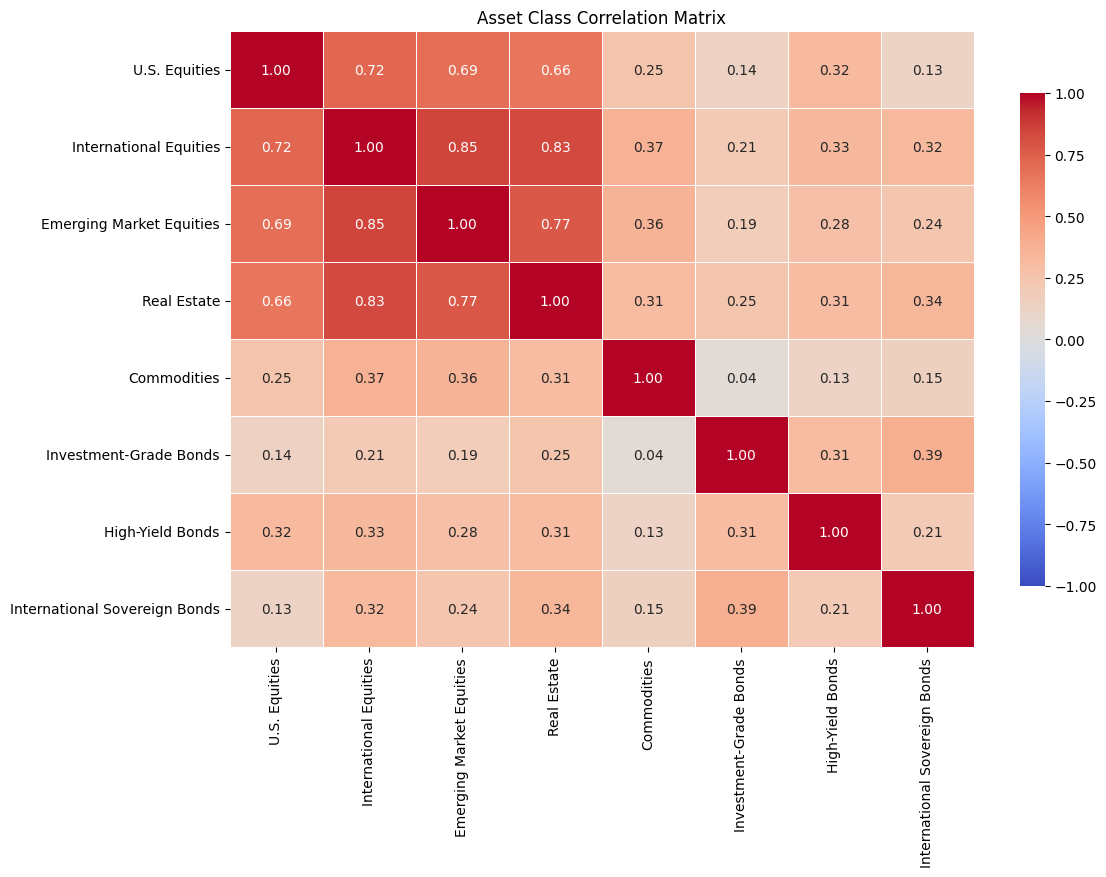

In [6]:
import seaborn as sns

# Calculate the correlation matrix of the daily returns
correlation_matrix = returns_df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            linewidths=0.5, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Asset Class Correlation Matrix')
plt.show()

In [7]:
equities, bonds = "U.S. Equities", "Investment-Grade Bonds"


two_asset_returns = returns_df[[equities, bonds]]
annual_mean_returns = two_asset_returns.mean() * trading_days_in_year
annual_cov_matrix = two_asset_returns.cov() * trading_days_in_year

# Annualize standard deviations
annual_std = two_asset_returns.std() * np.sqrt(trading_days_in_year)

# Display annualized metrics
print("Annualized Mean Returns:\n")
print(annual_mean_returns)
print("\nAnnualized Standard Deviations:")
print(annual_std)
print("\nAnnualized Covariance Matrix:")
annual_cov_matrix

Annualized Mean Returns:

U.S. Equities             0.095373
Investment-Grade Bonds    0.043070
dtype: float64

Annualized Standard Deviations:
U.S. Equities             0.194196
Investment-Grade Bonds    0.078697
dtype: float64

Annualized Covariance Matrix:


,U.S. Equities,Investment-Grade Bonds
U.S. Equities,0.037712,0.002164
Investment-Grade Bonds,0.002164,0.006193


We start by constructing two-asset portfolios consisting of U.S. equities and investment-grade bonds, experimenting with different equity/bond mixes. These portfolios will show us the increemental effect of adding and removing an asset class in a portfolio.

 Above, we observe the highest
risk-adjusted returns for portfolios with 30-40% weight on equities. Let us visualize this a bit differently. On the x-axis .....




INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


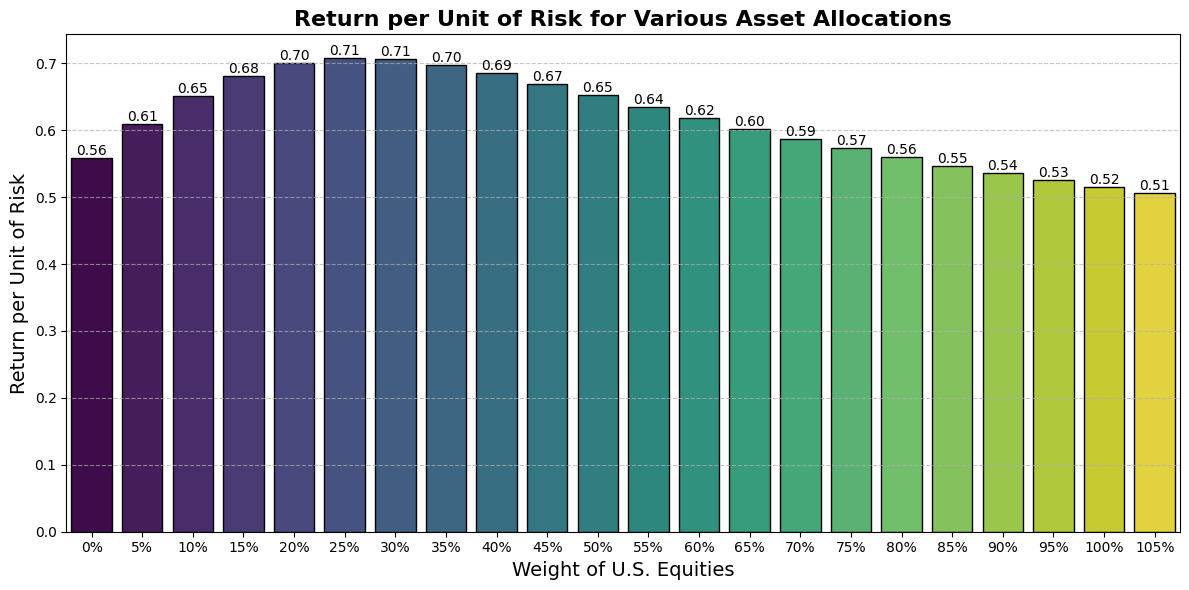

In [8]:

# Define portfolio weights
weights = np.arange(0, 1.1, 0.05)  # 0%, 10%, 20%, ..., 100%

# Initialize lists to store performance metrics
annualized_returns = []
annualized_risks = []
return_per_risk_ratios = []

# Calculate performance metrics for each portfolio
for weight in weights:
    # Define portfolio weights
    w_equities = weight
    w_bonds = 1 - weight
    
    # Portfolio returns and risk
    portfolio_returns = returns_df[equities] * w_equities + returns_df[bonds] * w_bonds
    annualized_return = (1 + portfolio_returns.mean()) ** trading_days_in_year - 1
    annualized_risk = portfolio_returns.std() * np.sqrt(trading_days_in_year)
    
    # Return-per-unit-of-risk ratio
    return_per_risk_ratio = annualized_return / annualized_risk if annualized_risk != 0 else np.nan
    
    # Store results
    annualized_returns.append(annualized_return)
    annualized_risks.append(annualized_risk)
    return_per_risk_ratios.append(return_per_risk_ratio)

results_df = pd.DataFrame({
    'Weight U.S. Equities': weights,
    'Weight U.S. Bonds': 1 - weights,
    'Annualized Return': annualized_returns,
    'Annualized Risk': annualized_risks,
    'Return per Unit of Risk': return_per_risk_ratios
})

plt.figure(figsize=(12, 6))

sns.barplot(x=results_df['Weight U.S. Equities'], 
            y=results_df['Return per Unit of Risk'],
            palette='viridis',hue= results_df['Weight U.S. Equities'],
            edgecolor='black', legend=False)

for i, value in enumerate(results_df['Return per Unit of Risk']):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom', fontsize=10, color='black')

plt.title('Return per Unit of Risk for Various Asset Allocations', fontsize=16, fontweight='bold')
plt.xlabel('Weight of U.S. Equities', fontsize=14)
plt.ylabel('Return per Unit of Risk', fontsize=14)
plt.xticks(ticks=range(len(results_df['Weight U.S. Equities'])), labels=[f'{int(w*100)}%' for w in results_df['Weight U.S. Equities']])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Coincidentally, we call the portfolio with highest risk-adjusted return (in terms of Sharpe ratio) the 'tangent' portfolio

Property: For two-asset portfolio, each mix will appear on what we call the efficient frontier.

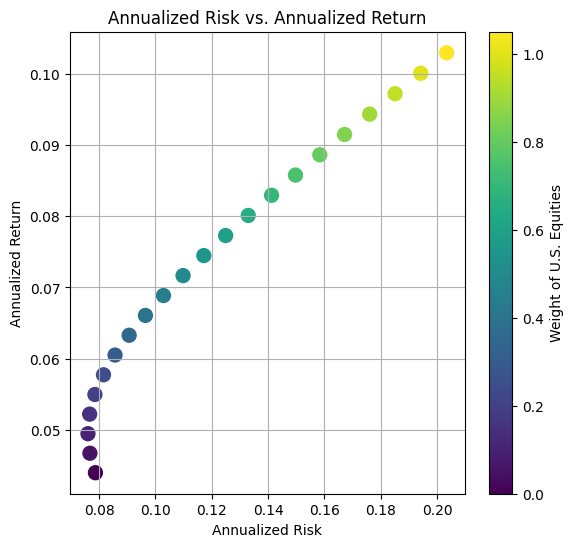

In [9]:
# Scatter plot of annualized risk vs. annualized return
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(results_df['Annualized Risk'], results_df['Annualized Return'], c=weights, cmap='viridis', s=100)

plt.colorbar(label='Weight of U.S. Equities')
plt.title('Annualized Risk vs. Annualized Return')
plt.xlabel('Annualized Risk')
plt.ylabel('Annualized Return')
plt.grid(True)

In [10]:
max_sharpe_portfolio = results_df.iloc[results_df['Return per Unit of Risk'].idxmax()]
max_sharpe_portfolio

Weight U.S. Equities       0.250000
Weight U.S. Bonds          0.750000
Annualized Return          0.057745
Annualized Risk            0.081562
Return per Unit of Risk    0.707991
Name: 5, dtype: float64

In [11]:
min_volatility_portfolio = results_df.iloc[results_df['Annualized Risk'].idxmin()] 
min_volatility_portfolio

Weight U.S. Equities       0.100000
Weight U.S. Bonds          0.900000
Annualized Return          0.049481
Annualized Risk            0.076048
Return per Unit of Risk    0.650654
Name: 2, dtype: float64

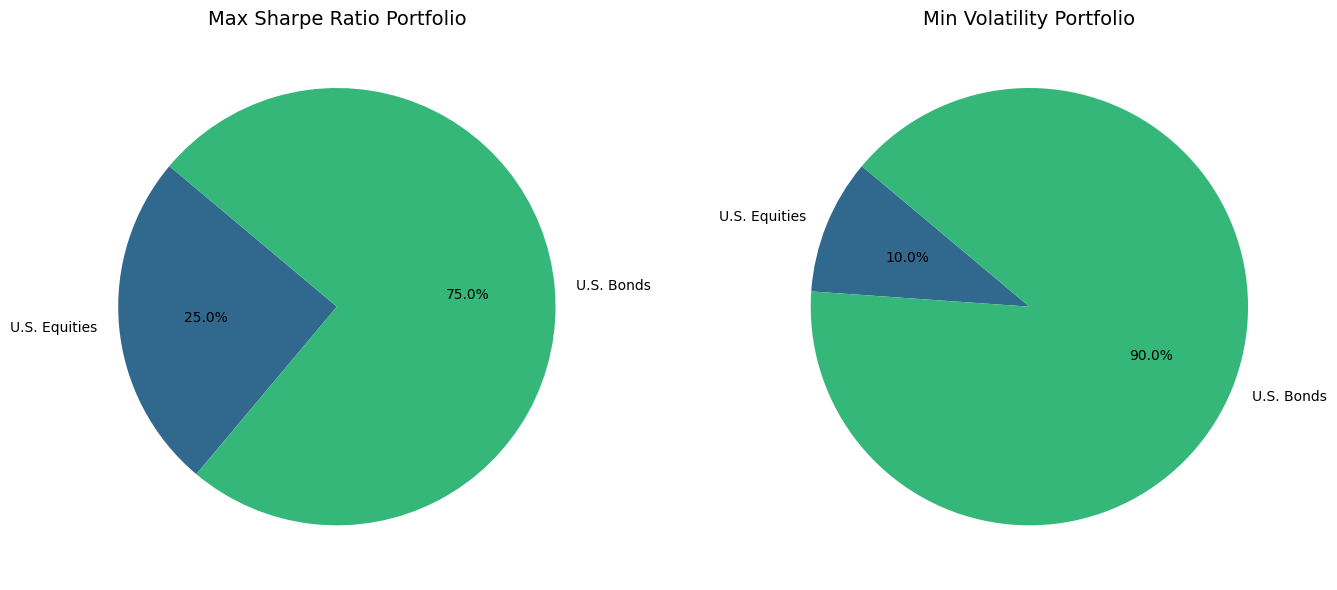

In [12]:
# Plot Asset Allocation of Optimal Portfolios as Pie Charts
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

tickers = list(map(lambda x: x.replace("Weight ", ""), list(max_sharpe_portfolio.iloc[:2].index)))
# Max Sharpe Ratio Portfolio
ax[0].pie(max_sharpe_portfolio.iloc[:2], labels=tickers, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(tickers)))
ax[0].set_title('Max Sharpe Ratio Portfolio', fontsize=14)
# Min Volatility Portfolio
ax[1].pie(min_volatility_portfolio.iloc[:2], labels=tickers, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(tickers)))
ax[1].set_title('Min Volatility Portfolio', fontsize=14)
plt.tight_layout()
plt.show()

Above proves Two Mutual Theorem. Let's include more asset classes

In [13]:
# Start with simple example
# Simulate expected returns for 4 assets (annualized)
expected_returns_synth = np.array([0.10, 0.12, 0.14, 0.08])

# Simulate a covariance matrix for these 4 assets
cov_matrix_synth = np.array([[0.1, 0.02, 0.04, 0.01],
                       [0.02, 0.08, 0.03, 0.02],
                       [0.04, 0.03, 0.09, 0.02],
                       [0.01, 0.02, 0.02, 0.07]])

In [14]:

import importlib
imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *

tangent_portfolio = get_tangent_portfolio(expected_returns=expected_returns_synth, cov_matrix=cov_matrix_synth)
tangent_return = portfolio_return_from_weights(weights=tangent_portfolio, returns=expected_returns_synth)
tangent_volatility = calculate_portfolio_volatility(weights=tangent_portfolio, cov_matrix=cov_matrix_synth)
print("Tangent Portfolio Weights:", tangent_portfolio)
print("Tangent Portfolio Returns:", tangent_return)
print("Tangent Portfolio Volatility:", tangent_volatility)

Tangent Portfolio Weights: [0.12601616 0.33116475 0.36421955 0.17859955]
Tangent Portfolio Returns: 0.11762008593027773
Tangent Portfolio Volatility: 0.20622686401794463


In [15]:
import importlib
imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *
# Get the Global Minimum Variance Portfolio
gmvp = get_global_minimum_variance_portfolio(cov_matrix_synth)
gmvp_return = portfolio_return_from_weights(weights=gmvp, returns=expected_returns_synth)
gmvp_volatility = calculate_portfolio_volatility(weights=gmvp, cov_matrix=cov_matrix_synth)
print("GMVP Weights:", gmvp)
print("GMVP Returns:", gmvp_return)
print("GMVP Volatility:", gmvp_volatility)

GMVP Weights: [0.22258074 0.25595646 0.14053973 0.38092308]
GMVP Returns: 0.10312225681570625
GMVP Volatility: 0.19185122240056254


At each level of risk, the investor would pick the portfolio mix with the highest returns. This forms the efficient frontier. In other words, at each level of desired return, we pick the portfolio with the least risk.

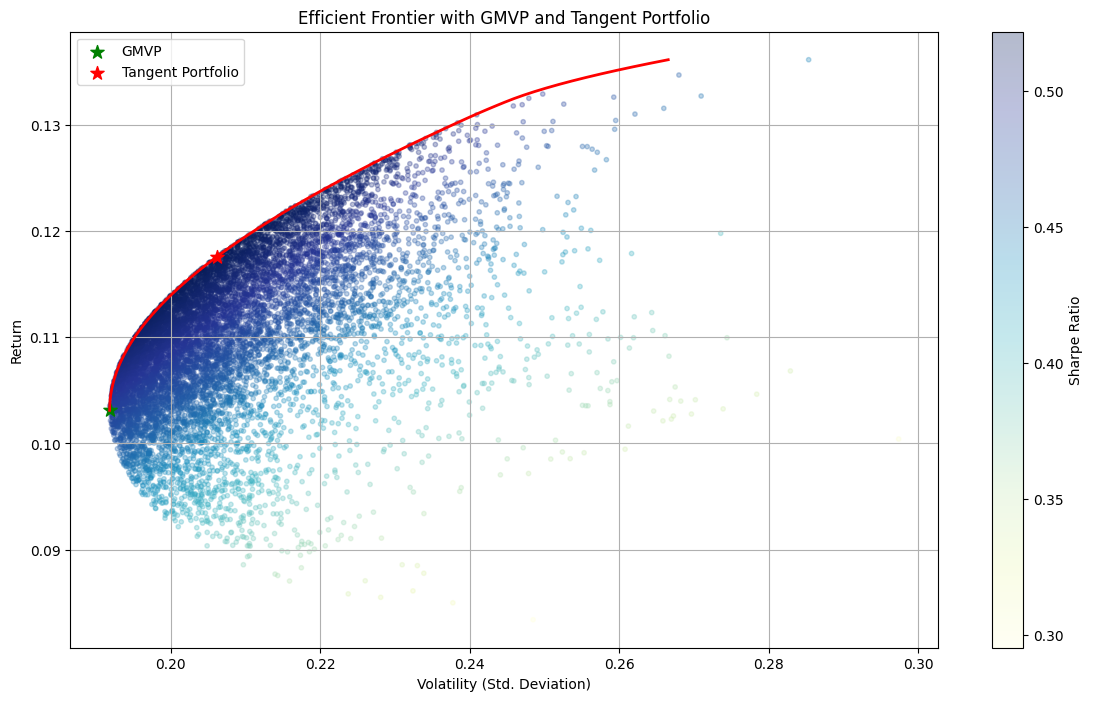

In [16]:
plot_efficient_frontier_and_portfolios(expected_returns_synth, cov_matrix_synth)

Now let's compare performance of an equal contribution portfolio against a mean-variance optimized one, rebalancing on a quarterly basis

In [17]:
frequency = 'daily'
annual_factor = annualized_factor_from_freq[frequency]
# Get mean returns and covariance matrix
expected_returns = annualized_expected_return(returns=returns_df)
cov_matrix = returns_df.cov() * annual_factor

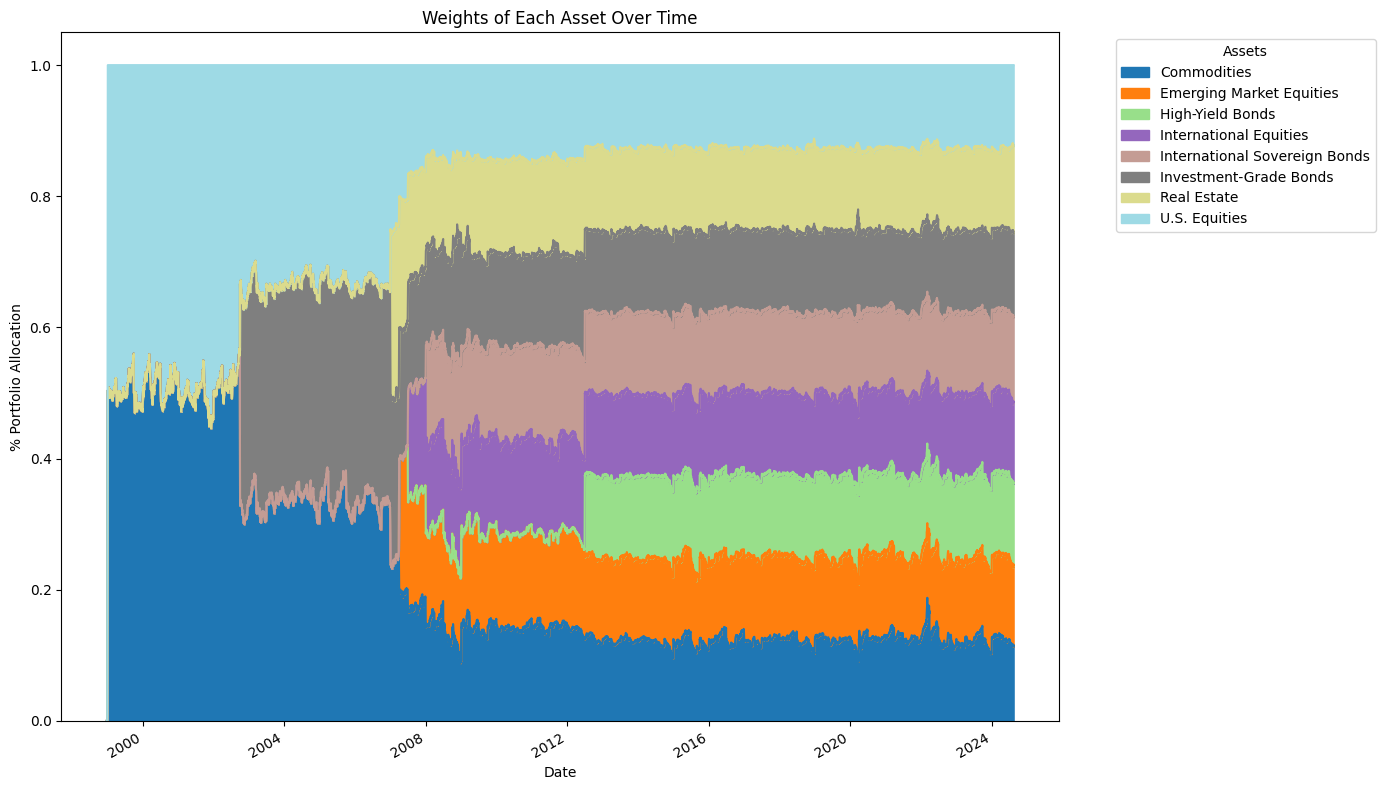

In [18]:
eq_portfolio_returns, eq_weights = calculate_historical_portfolio_allocation(returns=returns_df)
plot_weight_allocations(weights=eq_weights)

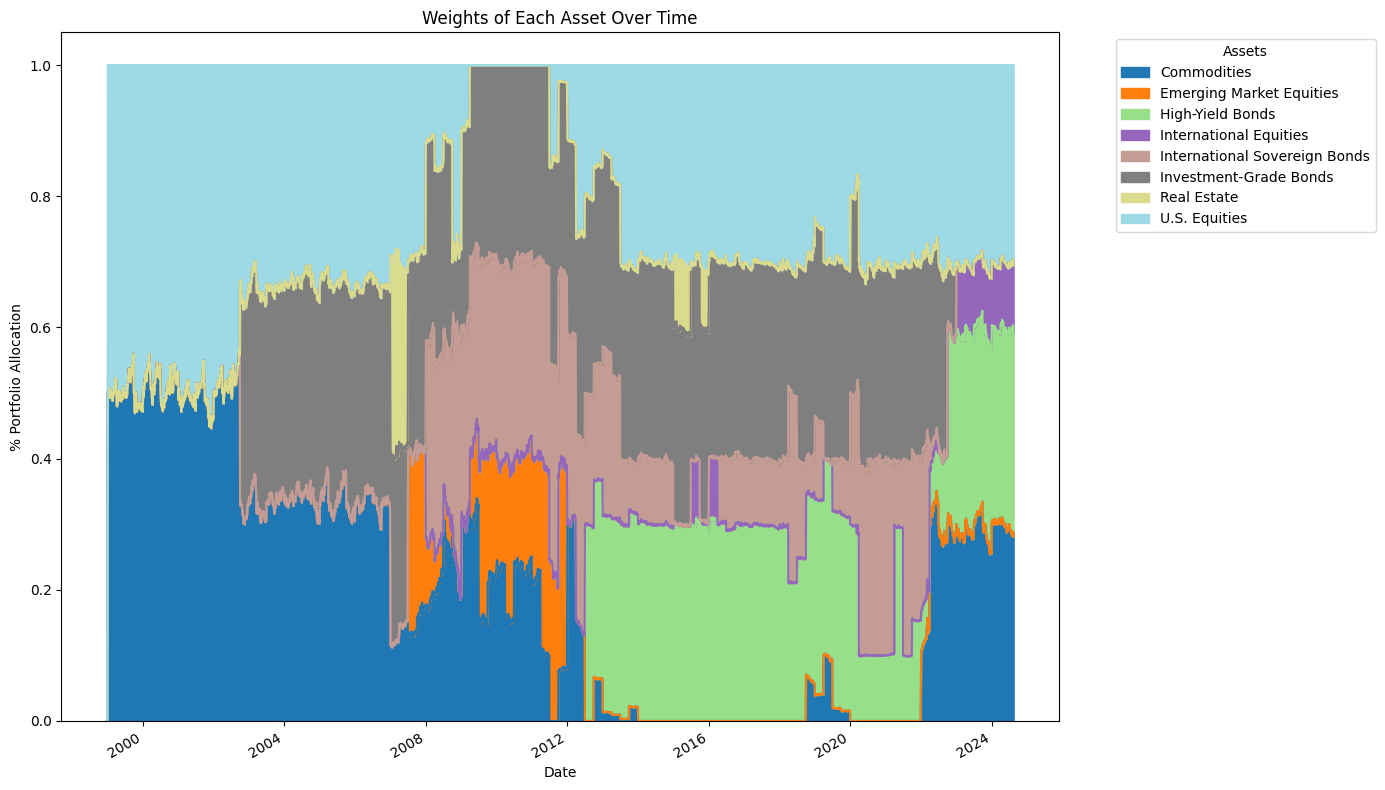

In [19]:
import importlib
imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *
sharpe_portfolio_returns, sharpe_weights = calculate_historical_portfolio_allocation(returns=returns_df,
                                                                                      objective_class=MaxSharpeRatio,
                                                                                     frequency='daily', 
                                                                                     max_exposure=0.3)
plot_weight_allocations(weights=sharpe_weights)

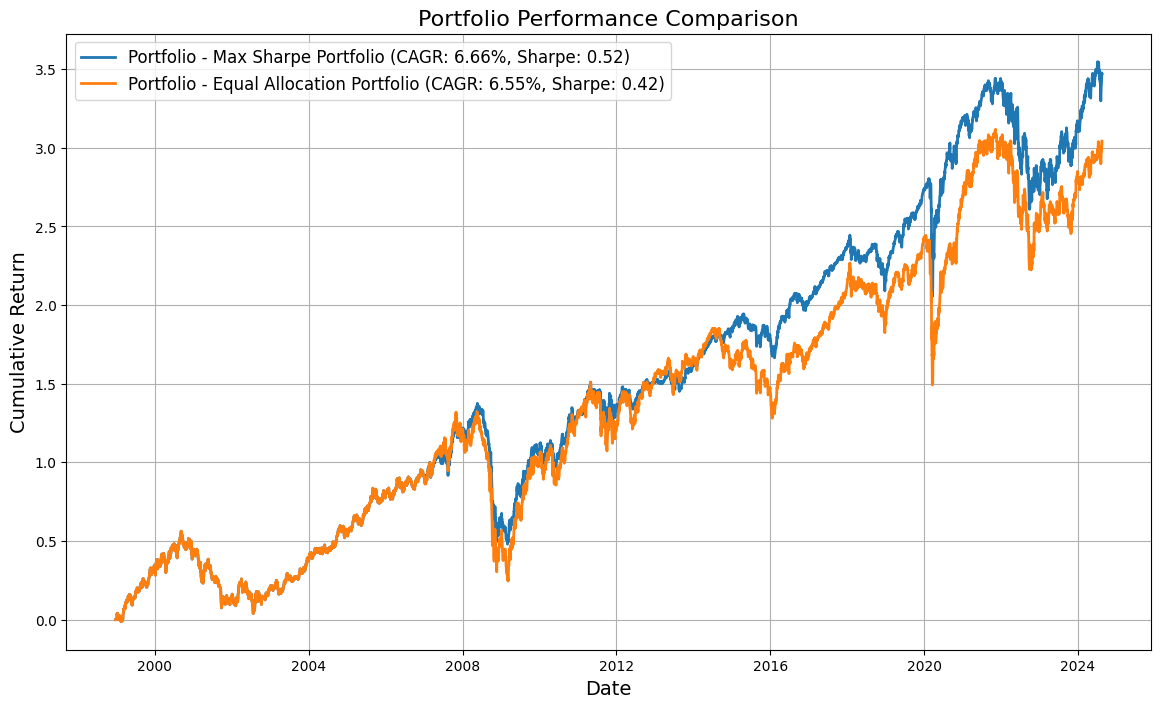

In [21]:
sharpe_returns_df = sharpe_portfolio_returns.to_frame(name="Max Sharpe Portfolio")
eq_returns_df = eq_portfolio_returns.to_frame(name="Equal Allocation Portfolio")
portf_and_bench_returns = sharpe_returns_df.join(eq_returns_df)

# Plot the performance
plot_portfolio_performance(returns_df=portf_and_bench_returns)


Current Recommendation

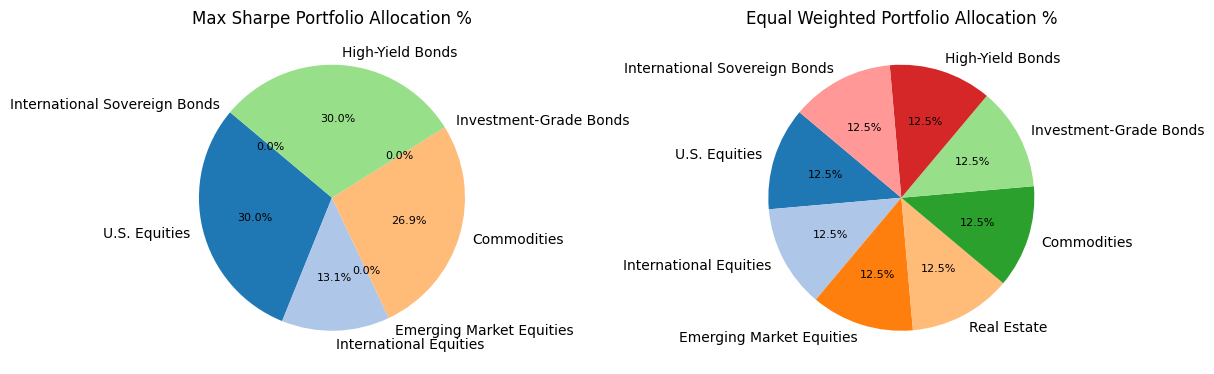

In [34]:
last_date = returns_df.index[-1]
start_date = last_date - pd.DateOffset(years=3)
recent_returns_df = returns_df.loc[start_date:]
weights_sharpe = portfolio_optimization(objective=MaxSharpeRatio(returns_df=recent_returns_df, frequency='daily'),
                                       max_exposure=0.3)
w_sh = pd.Series(weights_sharpe, index=recent_returns_df.columns)
weights_equal = np.array(recent_returns_df.shape[1] * [1 / recent_returns_df.shape[1]])
w_eq = pd.Series(weights_equal, index=recent_returns_df.columns)
plot_piecharts(items=[w_sh, w_eq], 
               titles=("Max Sharpe Portfolio Allocation %", "Equal Weighted Portfolio Allocation %"))

Our portfolio seemed to have given a better return, for a lower volatility, hence giving a higher Sharpe ratio.
Note: some abus de language
* Sharpe Ratio includes a risk-free rate. haven't mentioned here to keep it one concept at a time. better use "risk-adjusted return' or 'return per unit of risk'

In [35]:
portfolio_performance(portfolio_returns=sharpe_portfolio_returns, frequency="daily")

,inception,1Y,3Y,5Y,10Y
annualized_return,0.066598,0.121089,0.011469,0.055485,0.051610
annualized_volatility,0.109279,0.078378,0.106336,0.107098,0.085733
sharpe_ratio,0.517921,1.417349,0.013817,0.424705,0.485339


In [36]:
portfolio_performance(portfolio_returns=eq_portfolio_returns, frequency="daily")

,inception,1Y,3Y,5Y,10Y
annualized_return,0.065503,0.121763,0.006274,0.060293,0.042613
annualized_volatility,0.133181,0.082790,0.108880,0.126599,0.107667
sharpe_ratio,0.416745,1.349958,-0.034220,0.397266,0.302907


Modern Portfolio Theory is fundamentally sound, in the way that it computes portfolio volatility and returns given individual assets. However, given non-normally distributed assets:

Mean returns isn't necessarily a good proxy to Expected Returns (CLT, Law of Large Numbers). 

Portfolio volatiltiy isn't necessarily a good proxy to "Risk", and computing it using a standard covariance matrix contributes to the problem.

Overall risk is based on correlations; however, they are not static, but change over time...

Highly sensitive; can concentrate a big % to one asset, and nothing to others.

Highly dependent on timeframe (lookback period)



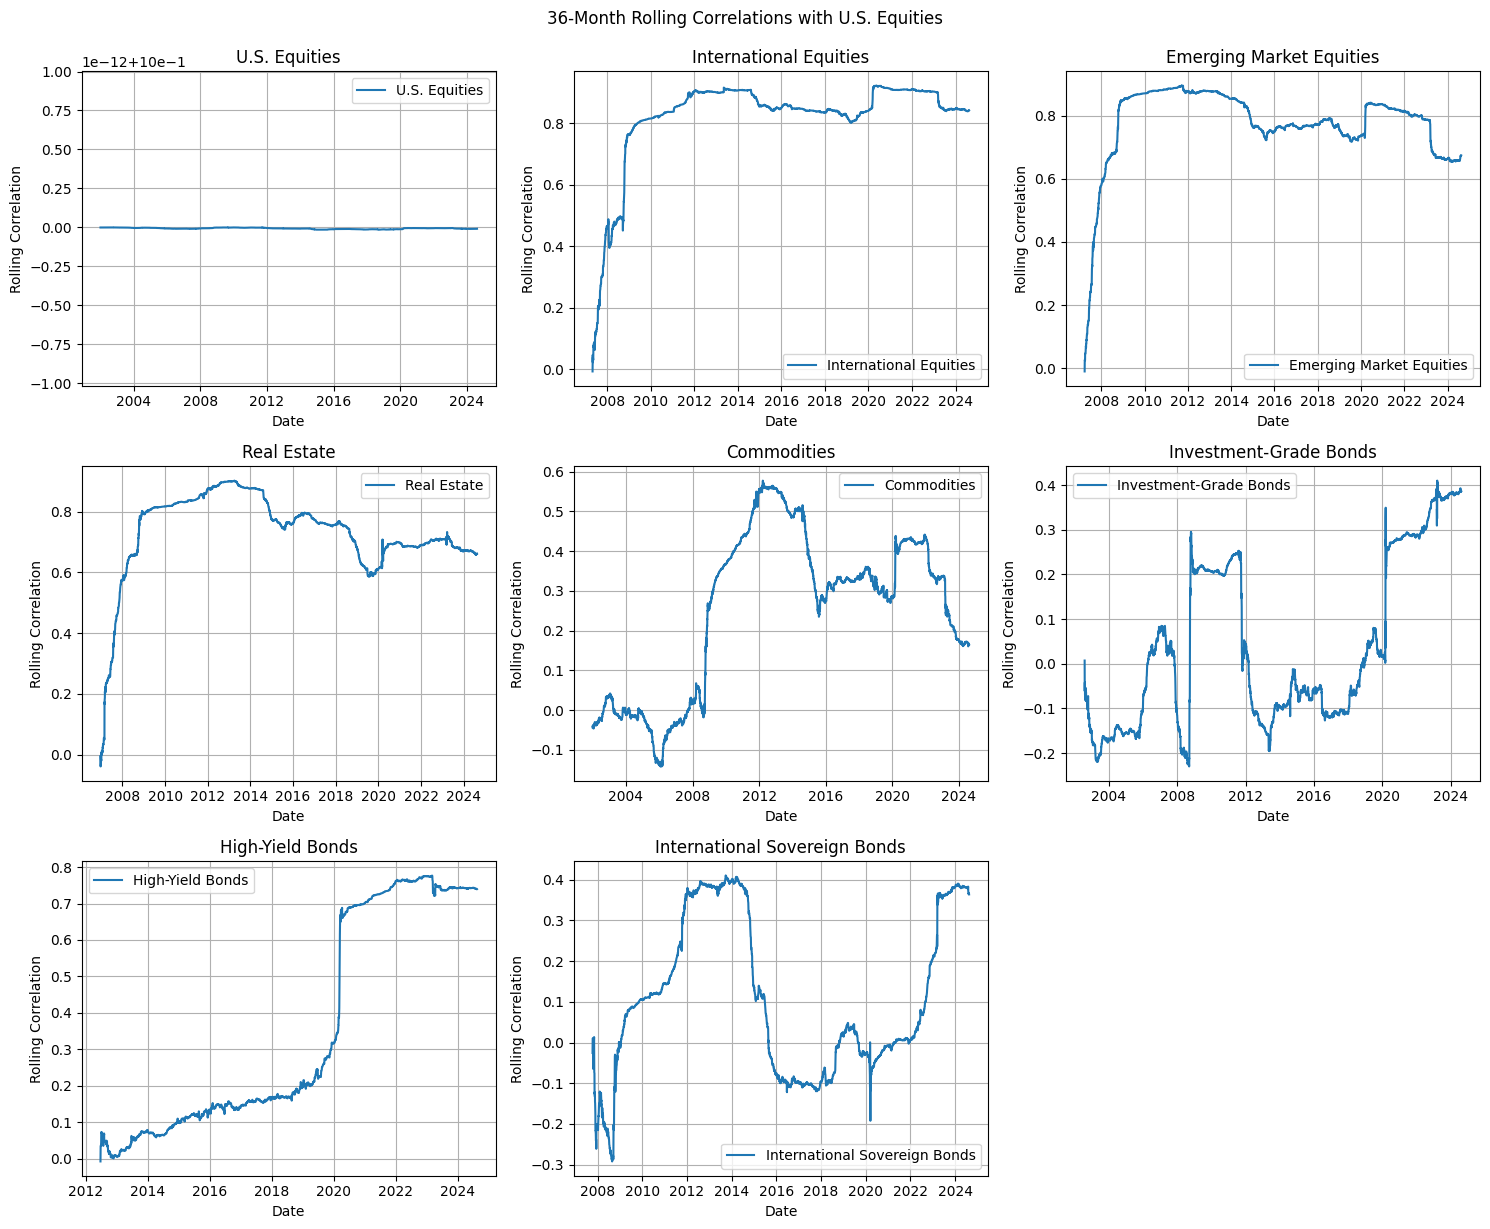

In [37]:
target_asset = 'U.S. Equities'  # Replace with your target asset class
comparison_assets = returns_df.columns  # Replace with your list of comparison asset classes
plot_rolling_correlations(returns_df, target_asset, comparison_assets, window_months=36)